# 03: Feature Engineering

**Goal:** Take the per-user feature table produced by the SQL notebook (`features_from_sql.parquet`),
augment it with a Python-side listening decay signal, engineer additional features, encode
categoricals, run a quick correlation and feature-importance check, and save a model-ready dataset.

**Input:** `data/features_from_sql.parquet` (from Notebook 02), raw CSVs for decay computation
**Output:** `data/model_ready.parquet`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "../../data/"

## 1. Load the SQL Feature Table

In [2]:
df = pd.read_parquet(DATA_DIR + "features_from_sql.parquet")
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['is_churn'].mean():.4f}  ({df['is_churn'].sum():,} churned / {len(df):,} total)")
df.head()

Shape: (933578, 11)
Churn rate: 0.0620  (57,895 churned / 933,578 total)


,msno,days_since_last_txn,plan_days_last,auto_renew_last,num_cancellations,auto_renew_rate,avg_discount_pct,log_days_last_30,avg_daily_secs_last_30,completion_rate_last_30,is_churn
0,//LNUhWtamiEonDJaM9O0hu7xxs/j3tMaxySZxd8TTY=,31,30,1,0,1.0,0.0,0,0.00,0.0000,0
1,//oTOh37hfJnouJhiAXqf6jnRuluWINHB0KE29mUII4=,30,30,1,0,1.0,0.0,28,6792.47,0.7478,0
2,//UqgHWjM+Vf0T7/IF4L0CNHaSFPOME0xd6ukFVC6b8=,30,30,1,0,1.0,0.0,0,0.00,0.0000,0
3,/+C1Lb0Q/4A24pGJEAnGsb7GfW8BIwEJZpV3xOAlfY4=,31,30,1,0,1.0,0.0,6,3879.33,0.6111,0
4,/+CaXsmQ4x86MXQoCKMqsGs/6Ndziu5aTRgeeW8ItXM=,32,30,1,0,1.0,0.0,14,8783.59,0.6979,0


In [3]:
df.describe()

,days_since_last_txn,plan_days_last,auto_renew_last,num_cancellations,auto_renew_rate,avg_discount_pct,log_days_last_30,avg_daily_secs_last_30,completion_rate_last_30,is_churn
count,933578.000000,933578.00000,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000
mean,37.795184,33.89412,0.911192,0.035223,0.912116,0.002034,5.788314,3935.665647,0.425990,0.062014
std,49.634529,33.27389,0.284466,0.187933,0.281911,0.038775,7.416361,6135.887755,0.380222,0.241181
min,-3.000000,0.00000,0.000000,0.000000,0.000000,-0.007900,0.000000,0.000000,0.000000,0.000000
25%,30.000000,30.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,30.00000,1.000000,0.000000,1.000000,0.000000,2.000000,2051.370000,0.516700,0.000000
75%,31.000000,30.00000,1.000000,0.000000,1.000000,0.000000,10.000000,5477.367500,0.781300,0.000000
max,2379.000000,450.00000,1.000000,8.000000,1.000000,1.000000,31.000000,614082.540000,1.000000,1.000000


## 2. Listening Decay Signal

For each user who has listening data, I computed the **slope of weekly `total_secs`** in the
4 weeks before their membership expiry date. A negative slope means the user's listening
was declining which is a strong pre-churn signal.

We need two raw files for this:
- `transactions_v2.csv` → get each user's latest `membership_expire_date`
- `user_logs_v2.csv` → daily listening `total_secs`

The user_logs file is ~1.4 GB / 30M rows, so we process it in chunks to manage memory.

In [4]:
# Load transactions to get the latest expiry date per user
txn = pd.read_csv(
    DATA_DIR + "transactions_v2.csv",
    usecols=["msno", "membership_expire_date"],
    dtype={"msno": str, "membership_expire_date": str},
)
txn["membership_expire_date"] = pd.to_datetime(
    txn["membership_expire_date"], format="%Y%m%d", errors="coerce"
)
# Keep the latest expiry per user
expiry = txn.groupby("msno")["membership_expire_date"].max().reset_index()
expiry.columns = ["msno", "expire_date"]
print(f"Users with expiry dates: {len(expiry):,}")
del txn

Users with expiry dates: 1,197,050


In [5]:
# Process user_logs in chunks: read -> join expiry -> filter to 28-day pre-expiry
# window -> aggregate per (msno, week) -> accumulate across chunks.

CHUNK = 2_000_000
reader = pd.read_csv(
    DATA_DIR + "user_logs_v2.csv",
    usecols=["msno", "date", "total_secs"],
    dtype={"msno": str, "date": str, "total_secs": float},
    chunksize=CHUNK,
)

agg_parts = []
rows_scanned = 0
rows_kept = 0

for i, chunk in enumerate(reader):
    rows_scanned += len(chunk)
    chunk["log_date"] = pd.to_datetime(chunk["date"], format="%Y%m%d", errors="coerce")
    chunk = chunk.merge(expiry, on="msno", how="inner")
    chunk["days_before"] = (chunk["expire_date"] - chunk["log_date"]).dt.days
    chunk = chunk[(chunk["days_before"] >= 0) & (chunk["days_before"] <= 27)]
    rows_kept += len(chunk)
    if len(chunk) == 0:
        continue
    chunk["week"] = (chunk["days_before"] // 7) + 1
    agg = chunk.groupby(["msno", "week"])["total_secs"].agg(["sum", "count"]).reset_index()
    agg_parts.append(agg)
    if (i + 1) % 5 == 0:
        print(f"  Processed {rows_scanned:,} rows...")

del expiry
print(f"Rows scanned: {rows_scanned:,}  |  Rows in 28-day window: {rows_kept:,}")

  Processed 10,000,000 rows...
  Processed 18,396,362 rows...
Rows scanned: 18,396,362  |  Rows in 28-day window: 5,212,211


In [6]:
# Combine chunk aggregates and compute per-user-per-week averages

weekly = pd.concat(agg_parts, ignore_index=True)
del agg_parts
weekly = weekly.groupby(["msno", "week"]).agg({"sum": "sum", "count": "sum"}).reset_index()
weekly["avg_secs"] = weekly["sum"] / weekly["count"]
weekly = weekly[["msno", "week", "avg_secs"]]
print(f"User-week pairs: {len(weekly):,}")

User-week pairs: 1,304,347


In [7]:
# Compute slope vectorized via pivot table + numpy
# slope = sum((x - x_mean)(y - y_mean)) / sum((x - x_mean)^2)
# x = week (1-4), y = avg_secs. Negative slope = declining listening.

pivot = weekly.pivot_table(index="msno", columns="week", values="avg_secs")
del weekly

n_weeks = pivot.notna().sum(axis=1)

week_cols = pivot.columns.values.astype(float)
x_vals = np.tile(week_cols, (len(pivot), 1))
mask_arr = pivot.notna().values

y_vals = pivot.fillna(0).values
counts = mask_arr.astype(float)

x_masked = np.where(mask_arr, x_vals, 0)
y_masked = np.where(mask_arr, y_vals, 0)

x_mean = x_masked.sum(axis=1) / np.maximum(counts.sum(axis=1), 1)
y_mean = y_masked.sum(axis=1) / np.maximum(counts.sum(axis=1), 1)

x_dev = np.where(mask_arr, x_vals - x_mean[:, None], 0)
y_dev = np.where(mask_arr, y_vals - y_mean[:, None], 0)

numerator = (x_dev * y_dev).sum(axis=1)
denominator = (x_dev ** 2).sum(axis=1)

slope_vals = np.where(
    (n_weeks >= 2) & (denominator > 0),
    numerator / denominator,
    np.nan,
)

slopes = pd.DataFrame({"msno": pivot.index, "listening_decay_slope": slope_vals})
del pivot, x_vals, y_vals, mask_arr, x_masked, y_masked

print(f"Users with decay slope: {slopes['listening_decay_slope'].notna().sum():,}")
print(f"Mean slope: {slopes['listening_decay_slope'].mean():.2f}")
print(f"Negative slopes (declining): {(slopes['listening_decay_slope'] < 0).sum():,}")

Users with decay slope: 396,196
Mean slope: 269.69
Negative slopes (declining): 178,042


In [8]:
# Merge onto main feature table

df = df.merge(slopes, on="msno", how="left")
del slopes

# Users without log data in the 28-day window get NaN — fill with 0 (no signal)
df["listening_decay_slope"].fillna(0.0, inplace=True)
print(f"Decay slope null count after fill: {df['listening_decay_slope'].isnull().sum()}")

Decay slope null count after fill: 0


## 3. Clean and Validate Features

In [9]:
# Check for any remaining nulls
print("Null counts:")
print(df.isnull().sum())

Null counts:
msno                       0
days_since_last_txn        0
plan_days_last             0
auto_renew_last            0
num_cancellations          0
auto_renew_rate            0
avg_discount_pct           0
log_days_last_30           0
avg_daily_secs_last_30     0
completion_rate_last_30    0
is_churn                   0
listening_decay_slope      0
dtype: int64


In [ ]:
# Cap outliers at 1st and 99th percentiles

cap_cols = ["days_since_last_txn", "avg_daily_secs_last_30", "listening_decay_slope"]

for col in cap_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    before_mean = df[col].mean()
    before_max = df[col].max()
    df[col] = df[col].clip(lower=q1, upper=q99)
    print(f"\n{col}:")
    print(f"  Clipped to [{q1:.2f}, {q99:.2f}]")
    print(f"  Before — mean: {before_mean:.2f}, max: {before_max:.2f}")
    print(f"  After  — mean: {df[col].mean():.2f}, max: {df[col].max():.2f}")


days_since_last_txn:
  Clipped to [0.00, 243.00]
  Before — mean: 37.80, max: 2379.00
  After  — mean: 35.54, max: 243.00

avg_daily_secs_last_30:
  Clipped to [0.00, 29359.09]
  Before — mean: 3935.67, max: 614082.54
  After  — mean: 3840.68, max: 29359.09

listening_decay_slope:
  Clipped to [-6693.58, 7494.06]
  Before — mean: 91.77, max: 390617.41
  After  — mean: 89.25, max: 7494.06


In [11]:
# Data leakage check: days_since_last_txn should be >= 0

neg_txn = (df["days_since_last_txn"] < 0).sum()
print(f"Rows with days_since_last_txn < 0: {neg_txn} ({neg_txn / len(df) * 100:.3f}%)")
# Edge cases from SQL window — clamp to 0
df["days_since_last_txn"] = df["days_since_last_txn"].clip(lower=0)

Rows with days_since_last_txn < 0: 0 (0.000%)


## 4. Feature Engineering

In [12]:
# Binary: is_discounted — user received a discount on average
df["is_discounted"] = (df["avg_discount_pct"] > 0).astype(int)

# Binary: high_cancel_flag — >= 2 cancellations signals flight risk
df["high_cancel_flag"] = (df["num_cancellations"] >= 2).astype(int)

# Composite: engagement score combining listening frequency and completion
df["log_engagement_score"] = df["log_days_last_30"] * df["completion_rate_last_30"]

# Categorical: plan type bucket from plan_days_last
def bucket_plan(days):
    if days <= 30:
        return "30d"
    elif days <= 90:
        return "90d"
    elif days <= 180:
        return "180d"
    else:
        return "365d"

df["plan_type_bucket"] = df["plan_days_last"].apply(bucket_plan)

print("New feature distributions:")
print(f"\nis_discounted:\n{df['is_discounted'].value_counts()}")
print(f"\nhigh_cancel_flag:\n{df['high_cancel_flag'].value_counts()}")
print(f"\nlog_engagement_score — mean: {df['log_engagement_score'].mean():.2f}, "
      f"median: {df['log_engagement_score'].median():.2f}")
print(f"\nplan_type_bucket:\n{df['plan_type_bucket'].value_counts()}")

New feature distributions:

is_discounted:
is_discounted
0    929904
1      3674
Name: count, dtype: int64

high_cancel_flag:
high_cancel_flag
0    933060
1       518
Name: count, dtype: int64

log_engagement_score — mean: 4.17, median: 1.05

plan_type_bucket:
plan_type_bucket
30d     915891
365d      9732
90d       4201
180d      3754
Name: count, dtype: int64


## 5. Encode Categoricals

In [13]:
# One-hot encode plan_type_bucket

plan_dummies = pd.get_dummies(df["plan_type_bucket"], prefix="plan", dtype=int)
df = pd.concat([df, plan_dummies], axis=1)
df.drop(columns=["plan_type_bucket"], inplace=True)

# auto_renew_last is already 0/1 — no encoding needed
print(f"Final columns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

Final columns (19):
['msno', 'days_since_last_txn', 'plan_days_last', 'auto_renew_last', 'num_cancellations', 'auto_renew_rate', 'avg_discount_pct', 'log_days_last_30', 'avg_daily_secs_last_30', 'completion_rate_last_30', 'is_churn', 'listening_decay_slope', 'is_discounted', 'high_cancel_flag', 'log_engagement_score', 'plan_180d', 'plan_30d', 'plan_365d', 'plan_90d']

Shape: (933578, 19)


## 6. Correlation Analysis

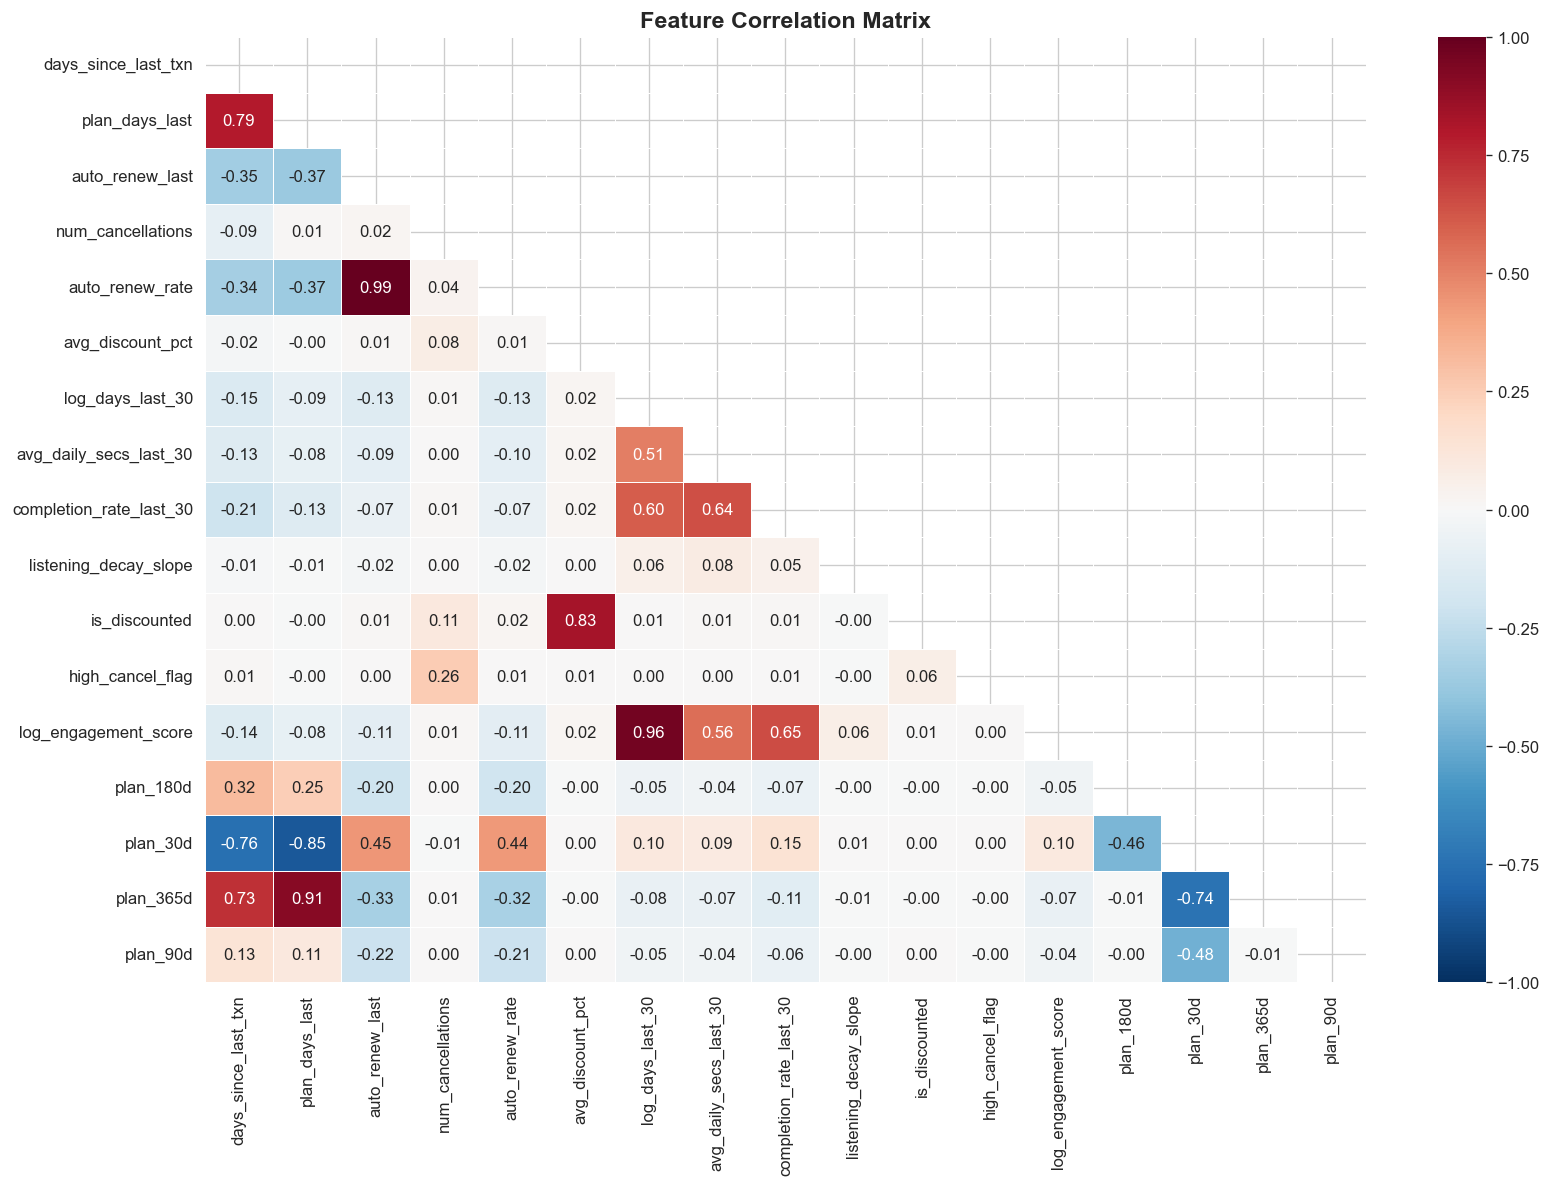

In [14]:
# Select numeric features (exclude msno and target)
feature_cols = [c for c in df.columns if c not in ["msno", "is_churn"]]
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig(DATA_DIR + "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Flag high-correlation pairs (|r| > 0.85)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

if high_corr_pairs:
    print("High-correlation pairs (|r| > 0.85):")
    for c1, c2, r in high_corr_pairs:
        print(f"  {c1}  <->  {c2}  :  r = {r:.3f}")
else:
    print("No feature pairs with |r| > 0.85 -- all clear.")

High-correlation pairs (|r| > 0.85):
  plan_days_last  <->  plan_365d  :  r = 0.911
  auto_renew_last  <->  auto_renew_rate  :  r = 0.995
  log_days_last_30  <->  log_engagement_score  :  r = 0.964


## 7. Feature Importance Preview

Quick `RandomForestClassifier` to rank features by importance.
This is NOT the final model just checking that engineered features carry signal.

In [16]:
X = df[feature_cols].copy()
y = df["is_churn"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Quick RF -- AUC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf.predict(X_test), target_names=["Retained", "Churned"]))

Quick RF -- AUC: 0.9882

Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.98      0.99    175137
     Churned       0.75      0.91      0.83     11579

    accuracy                           0.98    186716
   macro avg       0.87      0.95      0.91    186716
weighted avg       0.98      0.98      0.98    186716



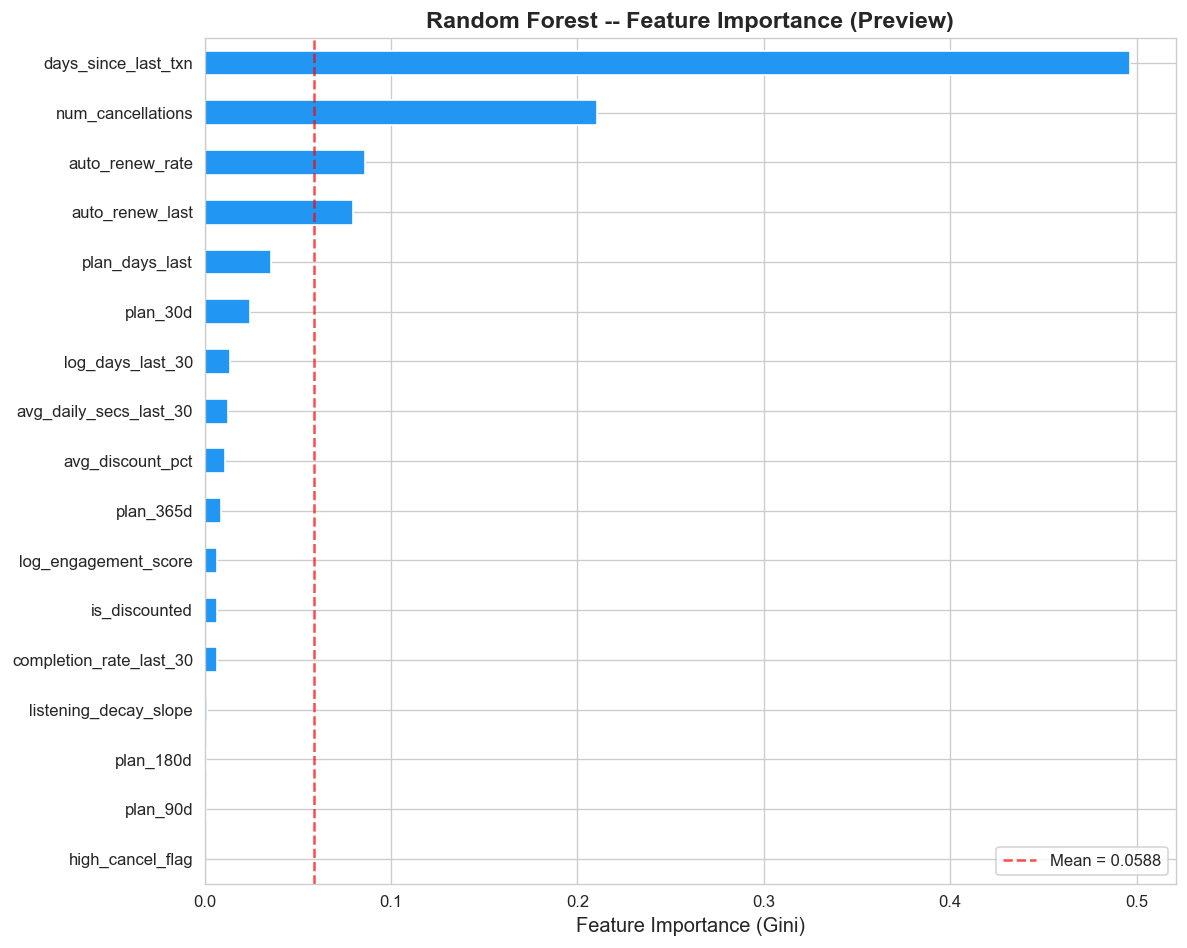


Top 5 features:
  days_since_last_txn             0.4964
  num_cancellations               0.2103
  auto_renew_rate                 0.0859
  auto_renew_last                 0.0795
  plan_days_last                  0.0357


In [17]:
# Feature importance plot

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind="barh", color="#2196F3", edgecolor="white", ax=ax)
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("Random Forest -- Feature Importance (Preview)", fontsize=14, fontweight="bold")
ax.axvline(
    x=importances.mean(), color="red", linestyle="--", alpha=0.7,
    label=f"Mean = {importances.mean():.4f}",
)
ax.legend()
plt.tight_layout()
#plt.savefig(DATA_DIR + "feature_importance_preview.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features:")
for feat, imp in importances.tail(5).iloc[::-1].items():
    print(f"  {feat:30s}  {imp:.4f}")

## 8. Save Model-Ready Dataset

In [19]:
# Drop msno (not a feature) — keep is_churn as target
df_model = df.drop(columns=["msno"])

print(f"Model-ready dataset shape: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1}")
print(f"Target balance: {df_model['is_churn'].value_counts().to_dict()}")

df_model.to_parquet(DATA_DIR + "model_ready.parquet", index=False)
print(f"\nSaved -> data/model_ready.parquet")

Model-ready dataset shape: (933578, 18)
Features: 17
Target balance: {0: 875683, 1: 57895}

Saved -> data/model_ready.parquet


In [20]:
# Final summary

print("=" * 120)
print("NOTEBOOK 03 -- FEATURE ENGINEERING SUMMARY")
print("=" * 120)
print(f"Input rows:     {len(df):,}")
print(f"Output rows:    {len(df_model):,}")
print(f"Output columns: {df_model.shape[1]} ({df_model.shape[1] - 1} features + target)")
print(f"Churn rate:     {df_model['is_churn'].mean():.4f}")
print(f"Preview RF AUC: {auc:.4f}")
print(f"\nFeatures in final dataset:")
for col in sorted(df_model.columns):
    if col != "is_churn":
        print(f"  - {col}")
print(f"\nTarget: is_churn")
print("=" * 120)

NOTEBOOK 03 -- FEATURE ENGINEERING SUMMARY
Input rows:     933,578
Output rows:    933,578
Output columns: 18 (17 features + target)
Churn rate:     0.0620
Preview RF AUC: 0.9882

Features in final dataset:
  - auto_renew_last
  - auto_renew_rate
  - avg_daily_secs_last_30
  - avg_discount_pct
  - completion_rate_last_30
  - days_since_last_txn
  - high_cancel_flag
  - is_discounted
  - listening_decay_slope
  - log_days_last_30
  - log_engagement_score
  - num_cancellations
  - plan_180d
  - plan_30d
  - plan_365d
  - plan_90d
  - plan_days_last

Target: is_churn
